In [1]:
import sys
sys.path.append('..')
from pathlib import Path
import numpy as np
import h5py
import jax
import jax.numpy as jnp
import yaml
import re
import collections
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
plt.style.use('../flowrec/utils/ppt.mplstyle')

import flowrec.training_and_states as state_utils
import flowrec.data as data_utils
import flowrec.physics_and_derivatives as derivatives

from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable
from matplotlib import gridspec
from scipy.interpolate import RBFInterpolator
from flowrec.utils import simulation
from flowrec import losses
from flowrec.utils.py_helper import slice_from_tuple
from flowrec.utils.system import set_gpu
from flowrec.utils.myplots import truegrey, create_custom_colormap, make_cax
cmap_trafficlight = create_custom_colormap('trafficlight')
from flowrec.utils import my_continuous_cmap, my_discrete_cmap

set_gpu(1,1)
# jax.config.update('jax_platform_name', 'cpu')

In [2]:
from flowrec.training_and_states import restore_trainingstate, params_split, params_merge, generate_update_fn, TrainingState
from flowrec.data import unnormalise_group, normalise

# Shared functions

## Stats of the repeats

- mean and standard deviation of relative error, physics loss 
- same for the time-averaged flow field
- list of folder names with corresponding loss values

In [3]:
def get_summary_onecase(
        results_dir, 
        predict_only=False, 
        history_only=False, 
        verbose=0):
    '''Return information about a single case'''

    if history_only:
        _result_file = Path(results_dir,'results.h5')
        hist= {}
        with h5py.File(_result_file,'r') as hf:
            hist['train'] = np.array(hf.get("loss_train"))
            hist['val'] = np.array(hf.get("loss_val"))
            hist['div'] = np.array(hf.get("loss_div"))
            hist['momentum'] = np.array(hf.get("loss_momentum"))
            hist['sensors'] = np.array(hf.get("loss_sensors"))
            hist['true'] = np.array(hf.get('loss_train_true'))
            hist['val_true'] = np.array(hf.get('loss_val_true'))
        return pd.DataFrame(hist)
        
    with open(Path(results_dir,'config.yml'),'r') as f:
        cfg = yaml.load(f, Loader=yaml.UnsafeLoader)

    cfg.data_config.update({'data_dir':'.'+cfg.data_config.data_dir})
    datacfg = cfg.data_config
    traincfg = cfg.train_config

    data, datainfo = cfg.case.dataloader(datacfg)
    # print(data.keys())
    if datacfg.shuffle:
        idx_shuffle, idx_unshuffle = data_utils.shuffle_with_idx(np.sum(datacfg.train_test_split), rng = np.random.default_rng(datacfg.randseed))
    _keys_to_exclude = [
        'u_train_clean',
        'u_val_clean',
        'train_minmax',
        'val_minmax',
        'u_train',
        'u_val',
        'inn_train',
        'inn_val'
    ]
    
    prep_data, make_model = cfg.case.select_model(datacfg=datacfg, mdlcfg=cfg.model_config, traincfg=traincfg)
    data = prep_data(data, datainfo)
    inn_train = data['inn_train']
    u_train = data['u_train']
    # print(u_train[0].shape)
    mdl = make_model(cfg.model_config)
    state = restore_trainingstate(results_dir,'state')


    if Path(results_dir, 'frozen_params.npy').exists():
        params_frozen = restore_trainingstate(results_dir, 'frozen_params')
        # print('These layers are frozen: ')
        # for l in list(params_frozen):
        #     print("  ",l)
        full_params = params_merge(params_frozen, state.params)
        full_params = params_merge(state.params, params_frozen)
    else:
        full_params = state.params
    # print('All layers: ')
    # for l in list(full_params):
    #     print("  ",l)
    if verbose==1:
        param_count = sum(x.size for x in jax.tree_util.tree_leaves(full_params))
        print(f'Total number of parameters {param_count:,}')

    pred_train = []
    for _inn in inn_train:
        pred_train.append(
            mdl.predict(full_params, _inn)
        )
    pred_train = np.concatenate(pred_train, axis=0)

    observe_kwargs = {key: value for key, value in data.items() if key not in _keys_to_exclude}
    take_observation, insert_observation = cfg.case.observe(
        datacfg,
        example_pred_snapshot = data['u_train'][0][0,...],
        example_pin_snapshot = data['inn_train'][0][0,...],
        **observe_kwargs
    )

    _, train_minmax = take_observation(np.concatenate(data['u_train'],axis=0), init=True)
    _, val_minmax = take_observation(np.concatenate(data['u_val'],axis=0),init=True)
    observed_train = [take_observation(_u) for _u in data['u_train']]
    observed_val = [take_observation(_u) for _u in data['u_val']]
    data.update({
        'y_train':observed_train,
        'y_val':observed_val,
        'train_minmax':train_minmax,
        'val_minmax':val_minmax 
    })

    _empty_data = jnp.zeros_like(data['u_train'][0][[0],...]) - 50.0
    _empty_data = insert_observation(_empty_data, observed_train[0][[0],...])
    _empty_data = np.squeeze(_empty_data)
    has_values = _empty_data > -50.0

    if predict_only:
        return pred_train, has_values
    
    if isinstance(u_train,list):
        ref = np.concatenate(u_train,0)


    return pred_train, has_values, ref, datainfo, data['forcing']

In [4]:
def get_losses_repeats(repeat_dir, prefix, history=False):
    folders = [f for f in repeat_dir.iterdir() if f.is_dir()]
    pattern = re.compile(f'^{prefix}')
    folders = [f for f in folders if re.search(pattern, f.name)]
    print(len(folders),folders)

    l = collections.defaultdict(list)
    for i in range(len(folders)):
        print(f'    run{i}')
        if i == 0:
            pred_train, has_values, ref, datainfo, forcing = get_summary_onecase(folders[i])
        else:
            pred_train, has_values = get_summary_onecase(folders[i], predict_only=True)

        l['rel-l2'].append(float(
            losses.relative_error(pred_train, ref)
        ))
        l['l2'].append(float(
            losses.mse(pred_train,ref)
        ))
        observed_ref = ref[:,has_values]
        observed_pred = pred_train[:,has_values]
        l['sensor'].append(float(
            losses.mse(observed_pred, observed_ref)
        ))
        with jax.default_device(jax.devices('cpu')[0]):
            l['momentum'].append(float(
                losses.momentum_loss(pred_train,datainfo,forcing=forcing)
            ))
            l['div'].append(float(
                losses.divergence(pred_train[...,:-1], datainfo)
            ))
    l['rel-l2'].append(np.nan)
    l['l2'].append(np.nan)
    l['sensor'].append(np.nan)
    with jax.default_device(jax.devices('cpu')[0]):
        l['momentum'].append(float(
            losses.momentum_loss(ref, datainfo, forcing=forcing)
        ))
        l['div'].append(float(
            losses.divergence(ref[...,:-1], datainfo, forcing=forcing)
        ))
    indexes = [f.name for f in folders]
    indexes.append('ref')
    df = pd.DataFrame(l, index=indexes)
    df['physics'] = df['momentum'] + df['div']
    df['total'] = df['physics'] + df['sensor']
    df.sort_values('total', inplace=True)
    return df, ref 

# Plots

In [ ]:
def plot_observations(snapshot, has_values, figsize=(5,5), s=1, highlight_inn=False):
    x, y, z, u = np.indices(snapshot.shape)
    x1 = x[has_values]
    y1 = y[has_values]
    z1 = z[has_values] 
    u1 = u[has_values]
    values = snapshot[has_values]
    if highlight_inn:
        alpha=0.5
    else:
        alpha=1

    # Flatten the arrays to use in scatter plot
    x1, y1, z1, u1, values = x1.flatten(), y1.flatten(), z1.flatten(), u1.flatten(), values.flatten()

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 2, wspace=0.7, right=0.85, bottom=0.05, left=0.05, top=0.95) 

    # Scatter plot where color is based on cube values
    axes = []
    labels = ['$u_1$','$u_2$','$u_3$','$p$']
    for i in range(4):
        ax = fig.add_subplot(gs[i], projection='3d')
        axes.append(ax)
        ax.view_init(elev=30, azim=120)
        ui = u1 == i
        sc = ax.scatter(x1[ui], y1[ui], z1[ui], c=values[ui], marker='.', s=s, alpha=alpha)
        ax.set_xlim(0.0, snapshot.shape[0])
        ax.set_ylim(0.0, snapshot.shape[1])
        ax.set_zlim(0.0, snapshot.shape[2])
        ax.set_xticks([2, snapshot.shape[0]-2], ['0', '$2\pi$'])
        ax.set_yticks([2, snapshot.shape[1]-2], ['0', '$2\pi$'])
        ax.set_zticks([2, snapshot.shape[2]-2], ['0', '$2\pi$'])
        ax.tick_params(pad=0.1, labelsize='x-small')
        ax.set_xlabel("$x_1$",fontsize='small')
        ax.set_ylabel("$x_2$",fontsize='small')
        ax.set_zlabel("$x_3$",fontsize='small')
        ax.set_title(labels[i], fontsize='medium')
    
    num_observed = np.count_nonzero(has_values)
    num_total = snapshot.size
    print(f'{num_observed} measurements, {num_observed/num_total:%} of the total {num_total} grid points.')

    if highlight_inn:
        inn_loc = has_values[...,-1] != has_values[...,0]
        inns = snapshot[inn_loc,-1]
        x2 = x[inn_loc,-1]
        y2 = y[inn_loc,-1]
        z2 = z[inn_loc,-1] 
        x2, y2, z2, inns = x2.flatten(), y2.flatten(), z2.flatten(), inns.flatten()
        axes[-1].scatter(x2, y2, z2, c=inns, marker='o', s=s, cmap='Reds', zorder=10)

    return fig, axes


# def plot_inn_sensor_loc(snapshot, has_values, figsize=(3,3), s=1):
#     inn_loc = has_values[...,-1] != has_values[...,0]

In [6]:
def plot_volumes(ref_snapshot, pred_snapshot, figsize=(6.5,2.5), label=None, titles=['',''], s=1):
    """snapshot of a single component"""
    x, y, z = np.indices(ref_snapshot.shape)
    # Flatten the arrays to use in scatter plot
    x1, y1, z1 = x.flatten(), y.flatten(), z.flatten()
    vmin, vmax = ref_snapshot.min(), ref_snapshot.max()

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(1, 3, width_ratios=[12, 12, 1], wspace=0.5, left=0.05, right=0.9) 
    cax = fig.add_subplot(gs[-1])

    # Scatter plot where color is based on cube values
    axes = []
    for i in range(2):
        ax = fig.add_subplot(gs[i], projection='3d')
        ax.view_init(elev=30, azim=120)
        ax.set_xlim(0.0, ref_snapshot.shape[0])
        ax.set_ylim(0.0, ref_snapshot.shape[1])
        ax.set_zlim(0.0, ref_snapshot.shape[2])
        ax.set_xticks([2, ref_snapshot.shape[0]-2], ['0', '$2\pi$'])
        ax.set_yticks([2, ref_snapshot.shape[1]-2], ['0', '$2\pi$'])
        ax.set_zticks([2, ref_snapshot.shape[2]-2], ['0', '$2\pi$'])
        ax.tick_params(pad=0.2, labelsize='x-small')
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
        ax.set_zlabel("$x_3$")
        ax.set_title(titles[i])
        axes.append(ax)
    sc0 = axes[0].scatter(x1, y1, z1, c=ref_snapshot.flatten(), marker='s', s=s, vmin=vmin, vmax=vmax, edgecolors=None)
    fig.colorbar(sc0, cax=cax, label=label)
    sc1 = axes[1].scatter(x1, y1, z1, c=pred_snapshot.flatten(), marker='s', s=s, vmin=vmin, vmax=vmax, edgecolors=None)
    return fig, axes

In [53]:
def plot_pdf(pred, ref, figsize=(6.5,2.5)):
    labels = ['$u\'_1$', '$u\'_2$', '$u\'_3$', '$p\'$']
    with jax.default_device(jax.devices("cpu")[0]):
        fig, axes = plt.subplots(1,4,figsize=figsize)
        for i,ax in enumerate(axes):
            counts,bins = np.histogram(ref[...,i].flatten()-np.mean(ref[...,i].flatten()), density=True, bins='auto')
            ax.stairs(counts,bins,label='Reference',linewidth=2,color=truegrey)
            counts,bins = np.histogram(pred[...,i].flatten()-np.mean(pred[...,i].flatten()), density=True, bins='auto')
            ax.stairs(counts,bins,label='Reconstructed',linewidth=1.5, color=my_discrete_cmap(0))
            ax.tick_params(labelsize='x-small')
            ax.set_xlabel(labels[i])
        axes[0].set_ylabel('Probability density')
        handles, labels = axes[0].get_legend_handles_labels()
        fig.subplots_adjust(top=0.8, wspace=0.4, bottom=0.2, right=0.95)
        fig.legend(handles=handles, ncol=2, loc='upper center', bbox_to_anchor=(0.5,1.0))
    return fig, axes

In [90]:
def plot_tke(ref, pred, datainfo, figsize=(3.5,2.5), linewidth=2, wavenumber=32, fgen=False, fnyquist=False):
    spectrum_true, kbins = derivatives.get_tke(ref-np.mean(ref,axis=0), datainfo, domain_size=2*np.pi*np.array(pred.shape[1:-1])/64.)
    spectrum_pred, kbins = derivatives.get_tke(pred-np.mean(pred,axis=0), datainfo, domain_size=2*np.pi*np.array(pred.shape[1:-1])/64.)
    f_generated = int(np.sqrt((ref.ndim-2)*wavenumber**2))
    gridsize = np.array(ref.shape[1:-1]) / 2.0
    f_nyquist = int(np.sqrt(np.sum(gridsize**2)))
    xmax = max(f_generated, f_nyquist)

    fig, ax = plt.subplots(1,1, figsize=figsize)
    fig.subplots_adjust(top=0.95, bottom=0.15, right=0.95, left=0.25)
    ax.semilogy(kbins, spectrum_true, label='Reference', color=truegrey, linewidth=linewidth+1)
    ax.semilogy(kbins, spectrum_pred, label='Reconstructed', color=my_discrete_cmap(0), linewidth=linewidth)
    if fgen:
        ax.vlines(f_generated, spectrum_true.min(), spectrum_true.max(),colors='k',linestyles='dotted', label='$k_{gen}$')
    if fnyquist:
        ax.vlines(f_nyquist, spectrum_true.min(), spectrum_true.max(),colors='k',linestyles='dashed', label='$k_{Nyquist}$')
    
    ax.set_xlim(0, xmax+3)
    ax.grid()
    ax.legend()
    ax.set_xlabel('Wavenumber',fontsize='medium')
    ax.set_ylabel('Turbulent Kinetic Energy',fontsize='medium')
    # handles, labels = ax.get_legend_handles_labels()
    # fig.legend(handles=handles, ncol=2, loc='upper center', bbox_to_anchor=(0.5,1.0))
    return fig, ax

# Extend 2D method

In [8]:
results_dir_2dmethod = Path('../local_results/3dkol/repeats_methods')
losses_2dmethod, ref = get_losses_repeats(results_dir_2dmethod, '2dmethod')

5 [PosixPath('../local_results/3dkol/repeats_methods/2dmethod-982-1984'), PosixPath('../local_results/3dkol/repeats_methods/2dmethod-436-4657'), PosixPath('../local_results/3dkol/repeats_methods/2dmethod-1092-729'), PosixPath('../local_results/3dkol/repeats_methods/2dmethod-849-2084'), PosixPath('../local_results/3dkol/repeats_methods/2dmethod-724-4329')]
    run0
    run1
    run2
    run3
    run4


In [9]:
print(losses_2dmethod.iloc[:-1,:].mean(), '\n', losses_2dmethod.iloc[:-1,:].std())
folders_2dmethod = list(losses_2dmethod.index[:-1])
print("Cases sorted by total loss ", folders_2dmethod)
losses_2dmethod

rel-l2      0.287826
l2          0.018265
sensor      0.016978
momentum    0.605158
div         0.128047
physics     0.733205
total       0.750182
dtype: float64 
 rel-l2      0.005510
l2          0.000699
sensor      0.000682
momentum    0.016957
div         0.017676
physics     0.029769
total       0.030109
dtype: float64
Cases sorted by total loss  ['2dmethod-849-2084', '2dmethod-1092-729', '2dmethod-436-4657', '2dmethod-724-4329', '2dmethod-982-1984']


,rel-l2,l2,sensor,momentum,div,physics,total
2dmethod-849-2084,0.285750,0.017997,0.016667,0.587163,0.101189,0.688352,0.705019
2dmethod-1092-729,0.292987,0.018920,0.017620,0.610797,0.121368,0.732164,0.749785
2dmethod-436-4657,0.280947,0.017397,0.016132,0.590740,0.144227,0.734966,0.751098
2dmethod-724-4329,0.285484,0.017964,0.016733,0.607861,0.130752,0.738613,0.755346
2dmethod-982-1984,0.293963,0.019047,0.017735,0.629229,0.142699,0.771928,0.789663
ref,NaN,NaN,NaN,0.137115,0.000250,0.137365,NaN


In [10]:
pred_2dmethod, sensors_2dmethod, ref, datainfo, forcing = get_summary_onecase(Path(results_dir_2dmethod,folders_2dmethod[0]))

In [11]:
with jax.default_device(jax.devices('cpu')[0]):
    vort = []
    vort_2dmethod = []
    batch = 500
    for i in range(ref.shape[0]//batch):
        _vort = derivatives.vorticity(ref[i*500:(i+1)*500,...,:-1], datainfo)
        vort.append(np.einsum('vt... -> t...v', _vort))
        _vort_2dmethod = derivatives.vorticity(pred_2dmethod[i*500:(i+1)*500,...,:-1], datainfo)
        vort_2dmethod.append(np.einsum('vt... -> t...v', _vort_2dmethod))

    vort = np.concatenate(vort, axis=0)
    vort_2dmethod = np.concatenate(vort_2dmethod, axis=0)

    v_abs = np.sqrt(np.einsum('t...v -> t...', vort**2))
    v_2dmethod_abs = np.sqrt(np.einsum('t...v -> t...', vort_2dmethod**2))

32318 measurements, 3.082085% of the total 1048576 grid points.
(64, 64, 64)
(64, 64, 64, 4)


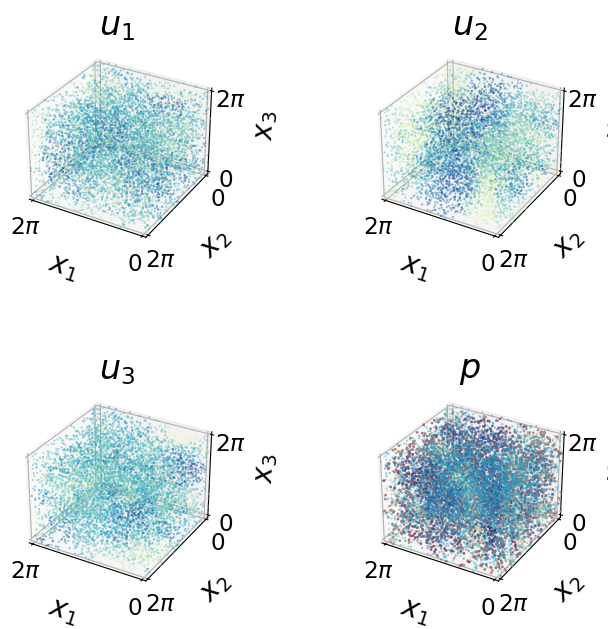

In [ ]:
fig1, axes = plot_observations(ref[0,...],has_values=sensors_2dmethod, figsize=(7,7), highlight_inn=True)
# fig1.savefig('sensors')

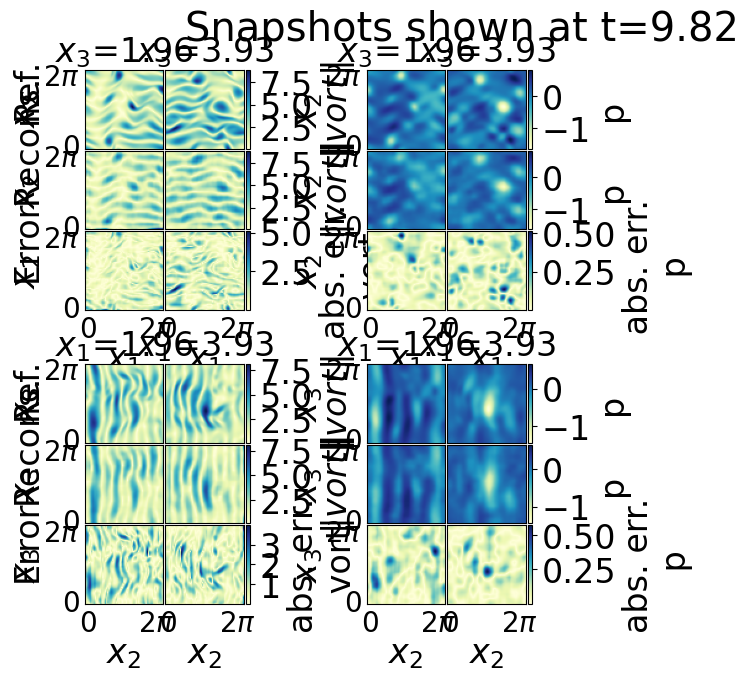

In [13]:
# for this case, plot the cross plane
# grid1a x-y planes at two z locations (ref, pred, error) vorticity, grid1b ... pressure.
# grid2a y-z planes at two x locations (ref, pred, error) vorticity, grid2b ... pressure.

index_plot = [20,40]
plt_t = 100

fig = plt.figure(figsize=(6,6))
grid1a = ImageGrid(fig, (0.08, 0.52, 0.42, 0.40), (3,2), cbar_mode='edge', share_all=True)
grid1b = ImageGrid(fig, (0.55, 0.52, 0.42, 0.40), (3,2), cbar_mode='edge', share_all=True)
grid2a = ImageGrid(fig, (0.08, 0.03, 0.42, 0.40), (3,2), cbar_mode='edge', share_all=True)
grid2b = ImageGrid(fig, (0.55, 0.03, 0.42, 0.40), (3,2), cbar_mode='edge', share_all=True)

fig.text(0.03,0.58,'Error',rotation=90)
fig.text(0.03,0.71,'Recons.',rotation=90)
fig.text(0.03,0.85,'Ref.',rotation=90)
fig.text(0.03,0.58-0.5,'Error',rotation=90)
fig.text(0.03,0.71-0.5,'Recons.',rotation=90)
fig.text(0.03,0.85-0.5,'Ref.',rotation=90)
fig.text(0.32,0.97, f'Snapshots shown at t={plt_t*datainfo.dx:.2f}', fontsize='large')

vplotz = v_abs[plt_t, :, :, index_plot] # advance index goes to the front
pplotz = ref[plt_t, :, :, index_plot, -1]
vplot_predz = v_2dmethod_abs[plt_t, :, :, index_plot]
pplot_predz = pred_2dmethod[plt_t, :, :, index_plot, -1]
vplotx = v_abs[plt_t, index_plot, :, :]
pplotx = ref[plt_t, index_plot, :, :, -1]
vplot_predx = v_2dmethod_abs[plt_t, index_plot, :, :]
pplot_predx = pred_2dmethod[plt_t, index_plot, :, :, -1]
vmax = [vplotz.max(),vplotx.max()]
vmin = [vplotz.min(),vplotx.min()]
pmax = [pplotz.max(),pplotx.max()]
pmin = [pplotz.min(),pplotx.min()]
num_snapshots = len(index_plot)
for i in range(num_snapshots):
    iref, ipred, ierr = i, i+num_snapshots, i+2*num_snapshots

    imvref = grid1a.axes_all[iref].imshow(vplotz[i,...].T, vmin=vmin[0], vmax=vmax[0])
    grid1a.cbar_axes[0].colorbar(imvref, label='$\|vort\|$')
    imvpred = grid1a.axes_all[ipred].imshow(vplot_predz[i,...].T, vmin=vmin[0], vmax=vmax[0])
    grid1a.cbar_axes[1].colorbar(imvpred, label='$\|vort\|$')
    imverr = grid1a.axes_all[ierr].imshow(np.abs(vplotz[i,...] - vplot_predz[i,...]).T)
    grid1a.cbar_axes[2].colorbar(imverr, label='abs. err.\n vort')
    
    impref = grid1b.axes_all[iref].imshow(pplotz[i,...].T, vmin=pmin[0], vmax=pmax[0])
    grid1b.cbar_axes[0].colorbar(impref, label='p')
    imppred = grid1b.axes_all[ipred].imshow(pplot_predz[i,...].T, vmin=pmin[0], vmax=pmax[0])
    grid1b.cbar_axes[1].colorbar(imppred, label='p')
    imperr = grid1b.axes_all[ierr].imshow(np.abs(pplotz[i,...] - pplot_predz[i,...]).T)
    grid1b.cbar_axes[2].colorbar(imperr, label=' abs. err.\n p')

    imvref = grid2a.axes_all[iref].imshow(vplotx[i,...].T, vmin=vmin[1], vmax=vmax[1])
    grid2a.cbar_axes[0].colorbar(imvref, label='$\|vort\|$')
    imvpred = grid2a.axes_all[ipred].imshow(vplot_predx[i,...].T, vmin=vmin[1], vmax=vmax[1])
    grid2a.cbar_axes[1].colorbar(imvpred, label='$\|vort\|$')
    imverr = grid2a.axes_all[ierr].imshow(np.abs(vplotx[i,...] - vplot_predx[i,...]).T)
    grid2a.cbar_axes[2].colorbar(imverr, label='abs. err.\n vort')
    
    impref = grid2b.axes_all[iref].imshow(pplotx[i,...].T, vmin=pmin[1], vmax=pmax[1])
    grid2b.cbar_axes[0].colorbar(impref, label='p')
    imppred = grid2b.axes_all[ipred].imshow(pplot_predx[i,...].T, vmin=pmin[1], vmax=pmax[1])
    grid2b.cbar_axes[1].colorbar(imppred, label='p')
    imperr = grid2b.axes_all[ierr].imshow(np.abs(pplotx[i,...] - pplot_predx[i,...]).T)
    grid2b.cbar_axes[2].colorbar(imperr, label='abs. err.\n p')

for grid in [grid1a, grid1b]:
    grid[0].set(yticks=[3,60], yticklabels=['0', '$2\pi$'], xticks=[2,58], xticklabels=['0', '$2\pi$'])
    grid.axes_all[0].set_title(f'$x_3$={index_plot[0]*datainfo.dz:.2f}', fontsize='medium')
    grid.axes_all[1].set_title(f'$x_3$={index_plot[1]*datainfo.dz:.2f}', fontsize='medium')
    for ax in grid.axes_all:
        ax.tick_params(length=0, labelsize='small')
        ax.set_xlabel('$x_1$',labelpad=0)
        ax.set_ylabel('$x_2$', labelpad=0)
for grid in [grid2a, grid2b]:
    grid[0].set(yticks=[3,60], yticklabels=['0', '$2\pi$'], xticks=[2,58], xticklabels=['0', '$2\pi$'])
    grid.axes_all[0].set_title(f'$x_1$={index_plot[0]*datainfo.dx:.2f}', fontsize='medium')
    grid.axes_all[1].set_title(f'$x_1$={index_plot[1]*datainfo.dx:.2f}', fontsize='medium')
    for ax in grid.axes_all:
        ax.tick_params(length=0, labelsize='small')
        ax.set_xlabel('$x_2$',labelpad=0.0)
        ax.set_ylabel('$x_3$', labelpad=0.0)

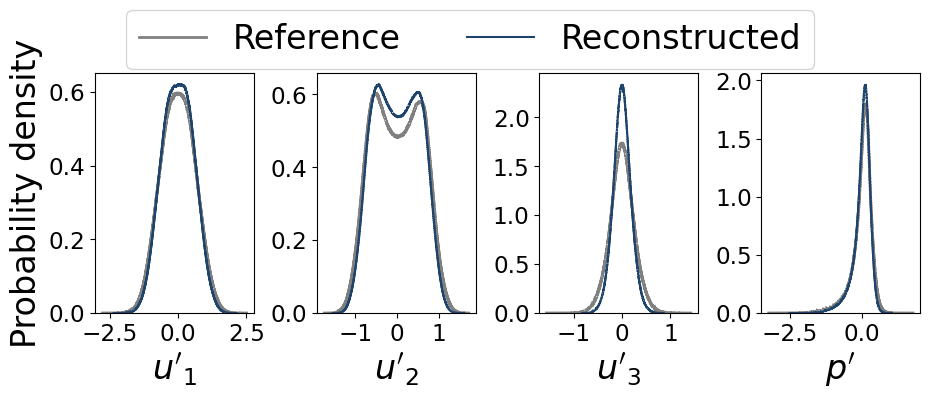

In [52]:
fig2,axes = plot_pdf(pred_2dmethod, ref, figsize=(10,4))
fig2.savefig('probability')

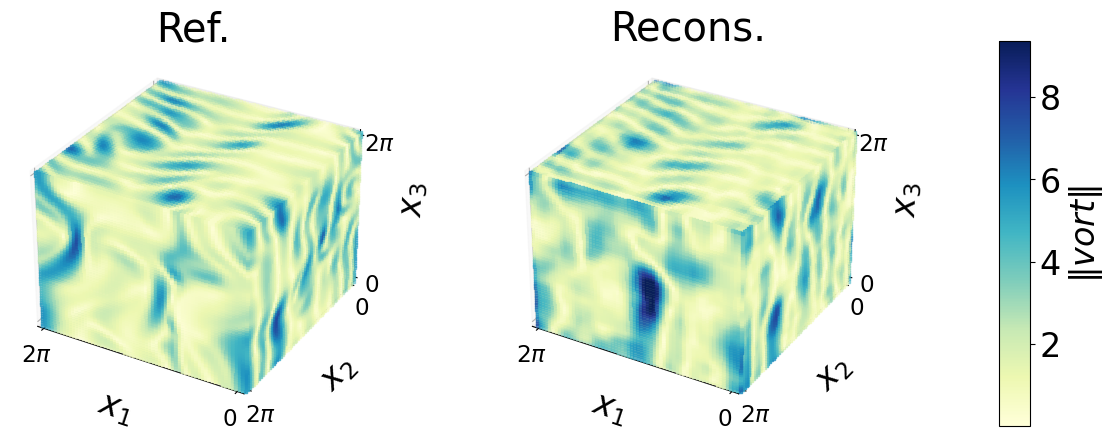

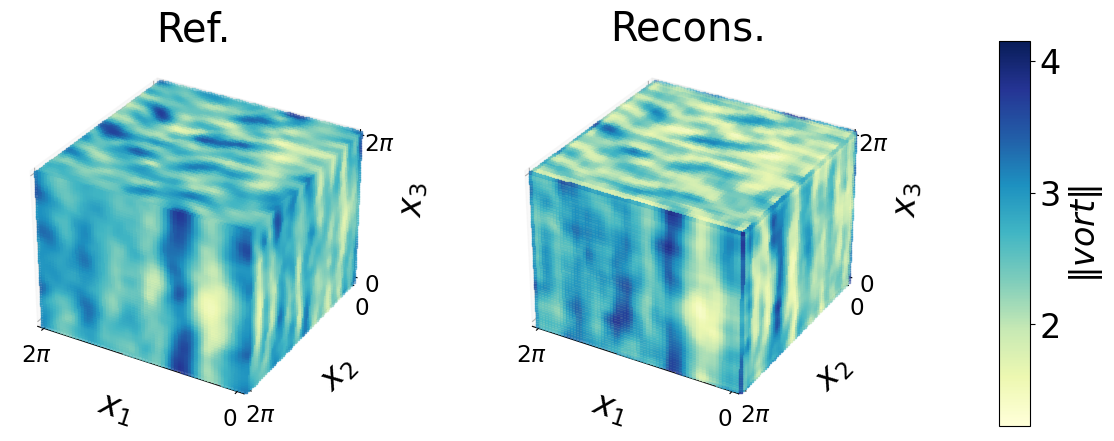

In [15]:
fig3, axes = plot_volumes(v_abs[plt_t,...], v_2dmethod_abs[plt_t,...], label='$\|vort\|$', titles=['Ref.', 'Recons.'], figsize=(12,5), s=4)
fig4, axes = plot_volumes(np.mean(v_abs,axis=0), np.mean(v_2dmethod_abs,axis=0), label='$\|vort\|$', titles=['Ref.', 'Recons.'], figsize=(12,5), s=4)
# fig3.savefig('volume-vort-snapshot')
# fig4.savefig('volume-vort-mean')

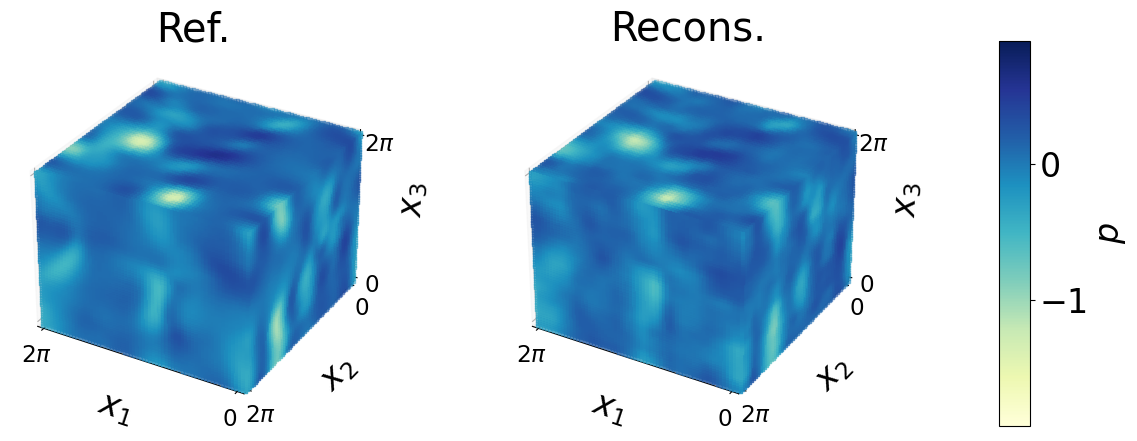

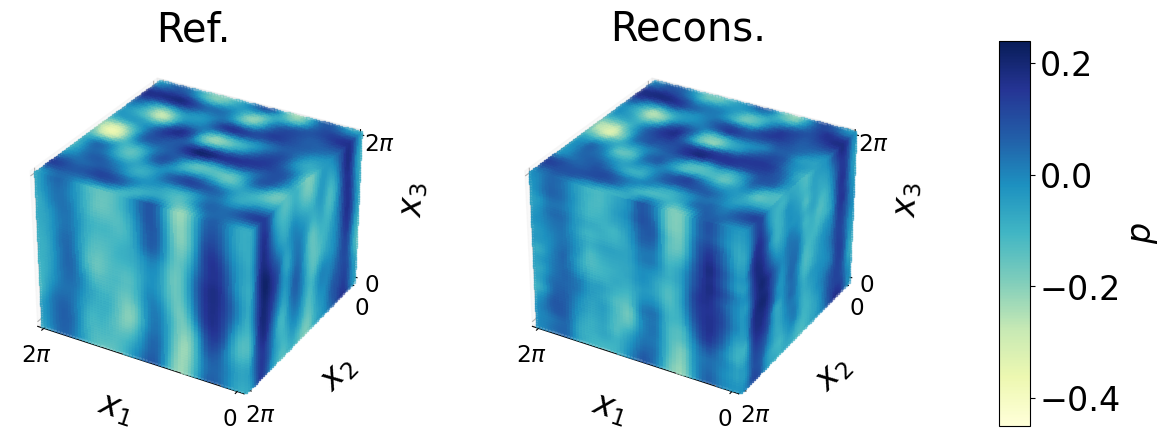

In [16]:
fig5, axes = plot_volumes(ref[plt_t,...,-1], pred_2dmethod[plt_t,...,-1], label='$p$', titles=['Ref.', 'Recons.'], figsize=(12,5), s=4)
fig6, axes = plot_volumes(np.mean(ref[...,-1],axis=0), np.mean(pred_2dmethod[...,-1],axis=0), label='$p$', titles=['Ref.', 'Recons.'], figsize=(12,5), s=4)
# fig5.savefig('volume-pressure-snapshot')
# fig6.savefig('volume-pressure-mean')

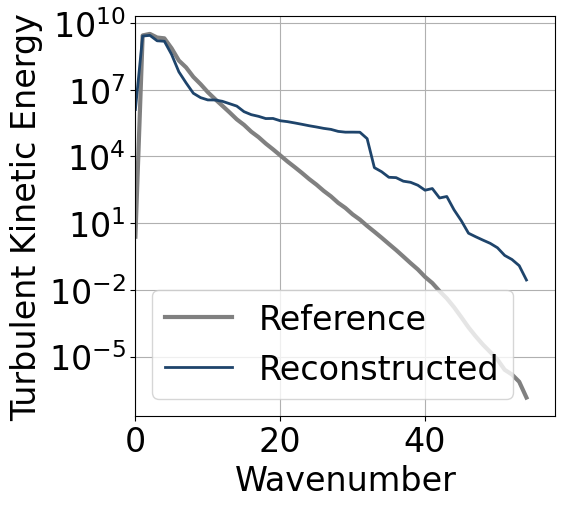

In [91]:
fig7, ax = plot_tke(ref, pred_2dmethod, datainfo, figsize=(6,5))
fig7.savefig('tke')

In [17]:
## 3d plots
# from plotly.subplots import make_subplots
# x, y, z = np.meshgrid(np.linspace(-1,1,20), np.linspace(-1,1,20), np.linspace(-1,1,20))
# values = np.sin(np.pi * x) * np.sin(np.pi * y) * np.sin(np.pi * z)

# # Create subplots with 2x2 layout and 3D support
# fig = make_subplots(
#     rows=2, cols=2,
#     specs=[[{'type': 'scene'}, {'type': 'scene'}],
#            [{'type': 'scene'}, {'type': 'scene'}]]
# )

# # Add 3D volume plots to each subplot
# for i in range(2):
#     for j in range(2):
#         scene_id = f'scene{i*2 + j + 1}'  # scene1, scene2, ...
#         fig.add_trace(
#             go.Volume(
#                 x=x.flatten(),
#                 y=y.flatten(),
#                 z=z.flatten(),
#                 value=values.flatten(),
#                 opacity=0.1,
#                 surface_count=15,
#                 showscale=False
#             ),
#             row=i+1, col=j+1
#         )

# # Optional: Customize each subplot layout
# fig.update_layout(
#     height=800,
#     width=800,
#     margin=dict(l=10, r=10, t=30, b=10),
#     scene=dict(aspectmode='cube'),
#     scene2=dict(aspectmode='cube'),
#     scene3=dict(aspectmode='cube'),
#     scene4=dict(aspectmode='cube')
# )

# fig.show()
